# Notebook 86 — Hough candidate-set shaping before aggregation

This notebook stays upstream of any raw-code patch. It keeps the same Python TimTrack candidate source and tests notebook-only shaping of Hough peaks before the weighted-median raw alpha: weight softening, duplicate collapse, and angle-family pruning.

In [1]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Markdown, Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPT = ROOT / 'scripts' / 'evaluate_hough_candidate_shaping.py'
OUT = ROOT / 'results' / 'notebook86_hough_candidate_shaping'
print(f'Project root: {ROOT}')
print(f'Script: {SCRIPT}')
print(f'Output directory: {OUT}')

Project root: /Users/grosbedou/PycharmProjects/NDORMS
Script: /Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_hough_candidate_shaping.py
Output directory: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook86_hough_candidate_shaping


In [2]:
completed = subprocess.run([sys.executable, str(SCRIPT)], check=True)
completed

Loading cached baseline geofeatures from /Users/grosbedou/PycharmProjects/NDORMS/results/notebook86_hough_candidate_shaping/baseline_geofeatures.pkl
Evaluating candidate-shaping variant: baseline_current
Evaluating candidate-shaping variant: sqrt_weights
Evaluating candidate-shaping variant: dedup_gap1_sum
Evaluating candidate-shaping variant: dedup_gap2_sum
Evaluating candidate-shaping variant: top_peak_family_5deg
Evaluating candidate-shaping variant: dominant_window_8deg
Evaluating candidate-shaping variant: dedup1_plus_dominant8
# Notebook 86 — Hough candidate-set shaping before aggregation

Recomputed the baseline TimTrack candidate stream for 2666 aligned frames and cached it at `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook86_hough_candidate_shaping/baseline_geofeatures.pkl`.

This notebook stays upstream of any code patch. It keeps the same raw TimTrack image path, then tests whether reshaping the Hough peak set before the weighted-median alpha can improve parity.

#

CompletedProcess(args=['/Library/Developer/CommandLineTools/usr/bin/python3', '/Users/grosbedou/PycharmProjects/NDORMS/scripts/evaluate_hough_candidate_shaping.py'], returncode=0)

In [3]:
display(Markdown((OUT / 'notebook86_summary.md').read_text()))

# Notebook 86 — Hough candidate-set shaping before aggregation

Recomputed the baseline TimTrack candidate stream for 2666 aligned frames and cached it at `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook86_hough_candidate_shaping/baseline_geofeatures.pkl`.

This notebook stays upstream of any code patch. It keeps the same raw TimTrack image path, then tests whether reshaping the Hough peak set before the weighted-median alpha can improve parity.

## Candidate-shaping findings

- The baseline identity variant reproduces the saved Python raw alpha exactly (raw-vs-saved RMSE 0.000000 deg), so the notebook is testing the same candidate stream as the strict run.
- The best raw-alpha RMSE against MATLAB geofeature alpha is `baseline_current` at 2.8086 deg, versus 2.8086 deg for the unshaped baseline.
- The best downstream FL RMSE after the same persistence and Kalman path is `top_peak_family_5deg` at 1.5137 mm, versus 2.0116 mm for the baseline.
- The lowest rate of 'good candidate present but raw >5 deg wrong' is `top_peak_family_5deg` at 0.0034, versus 0.0544 for baseline.

## Interpretation

- If candidate-set shaping helps on the same source peaks, that points to family structure and duplicate/weight bias inside the raw Hough candidate stream.
- If shaping helps FL but not raw MATLAB parity, it is still a compensating modeling change rather than a clean parity fix.
- If baseline remains best, the unresolved difference is even earlier: candidate generation and mask construction, not just peak-family shaping.

- Raw metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook86_hough_candidate_shaping/shaping_raw_metrics.csv`
- Persistence metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook86_hough_candidate_shaping/shaping_persistence_metrics.csv`
- Downstream metrics CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook86_hough_candidate_shaping/shaping_downstream_metrics.csv`
- Combined summary CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook86_hough_candidate_shaping/shaping_full_summary.csv`
- Per-frame CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook86_hough_candidate_shaping/shaping_per_frame.csv`
- Summary plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook86_hough_candidate_shaping/shaping_variant_summary.png`
- Trace plot: `/Users/grosbedou/PycharmProjects/NDORMS/results/notebook86_hough_candidate_shaping/shaping_variant_traces.png`


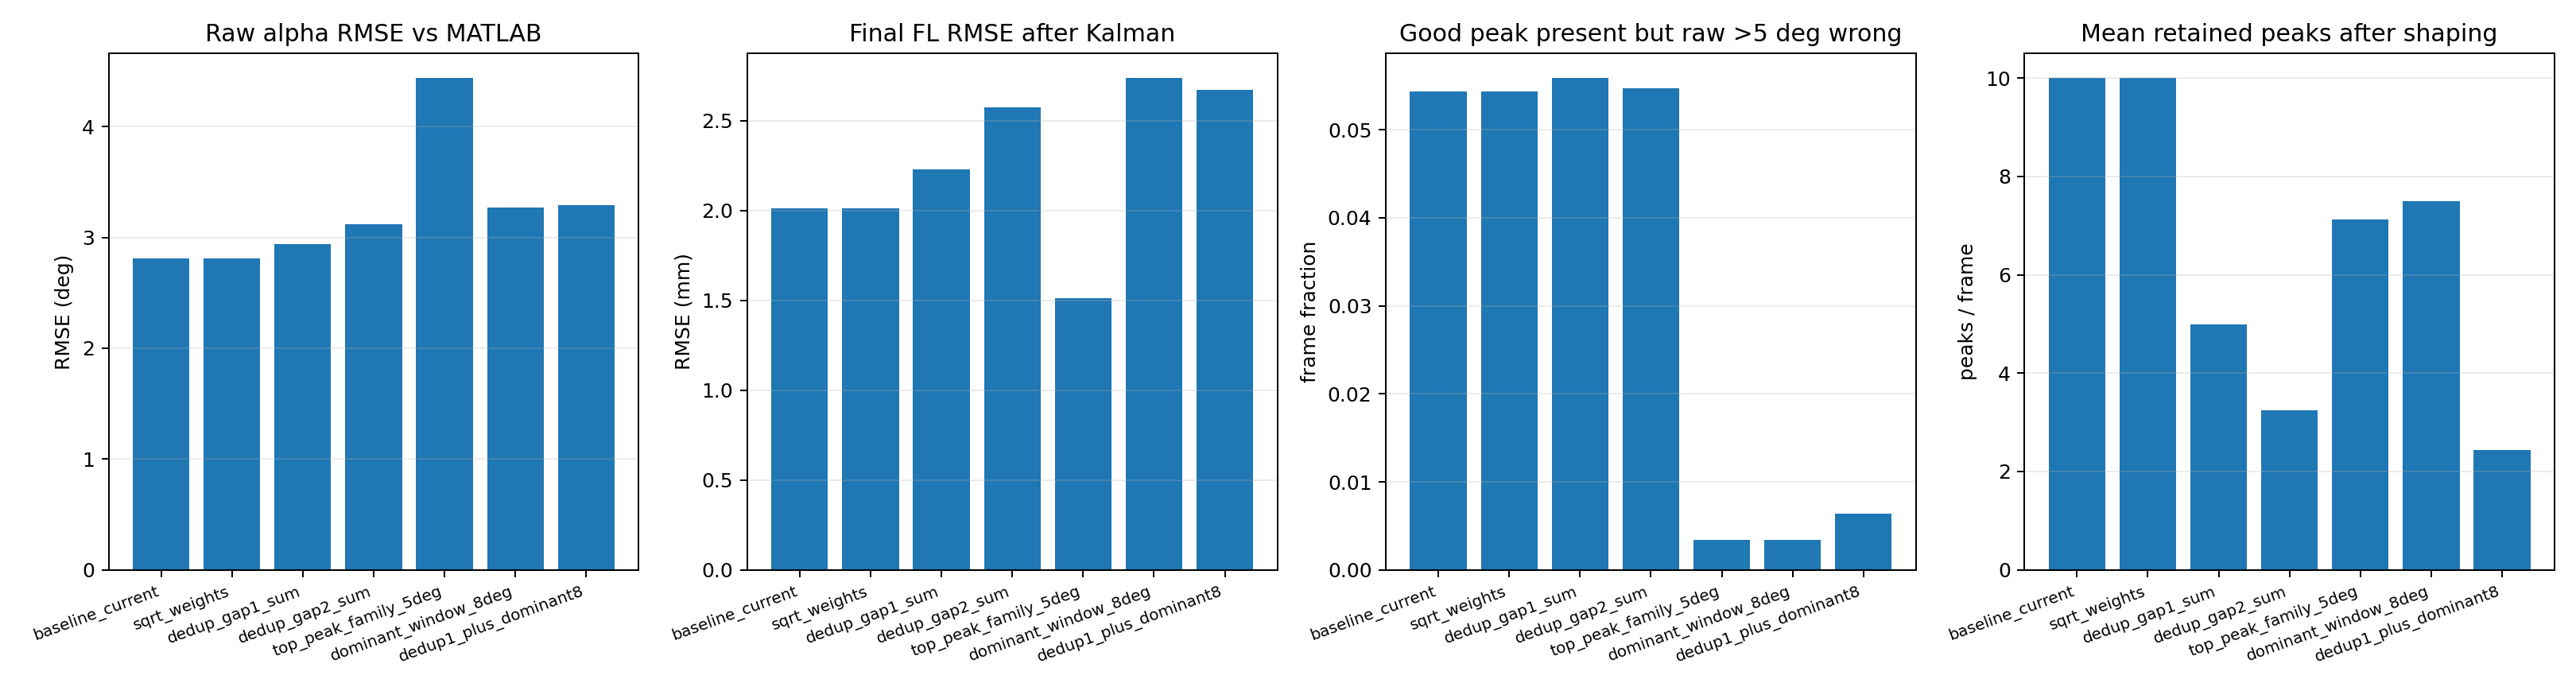

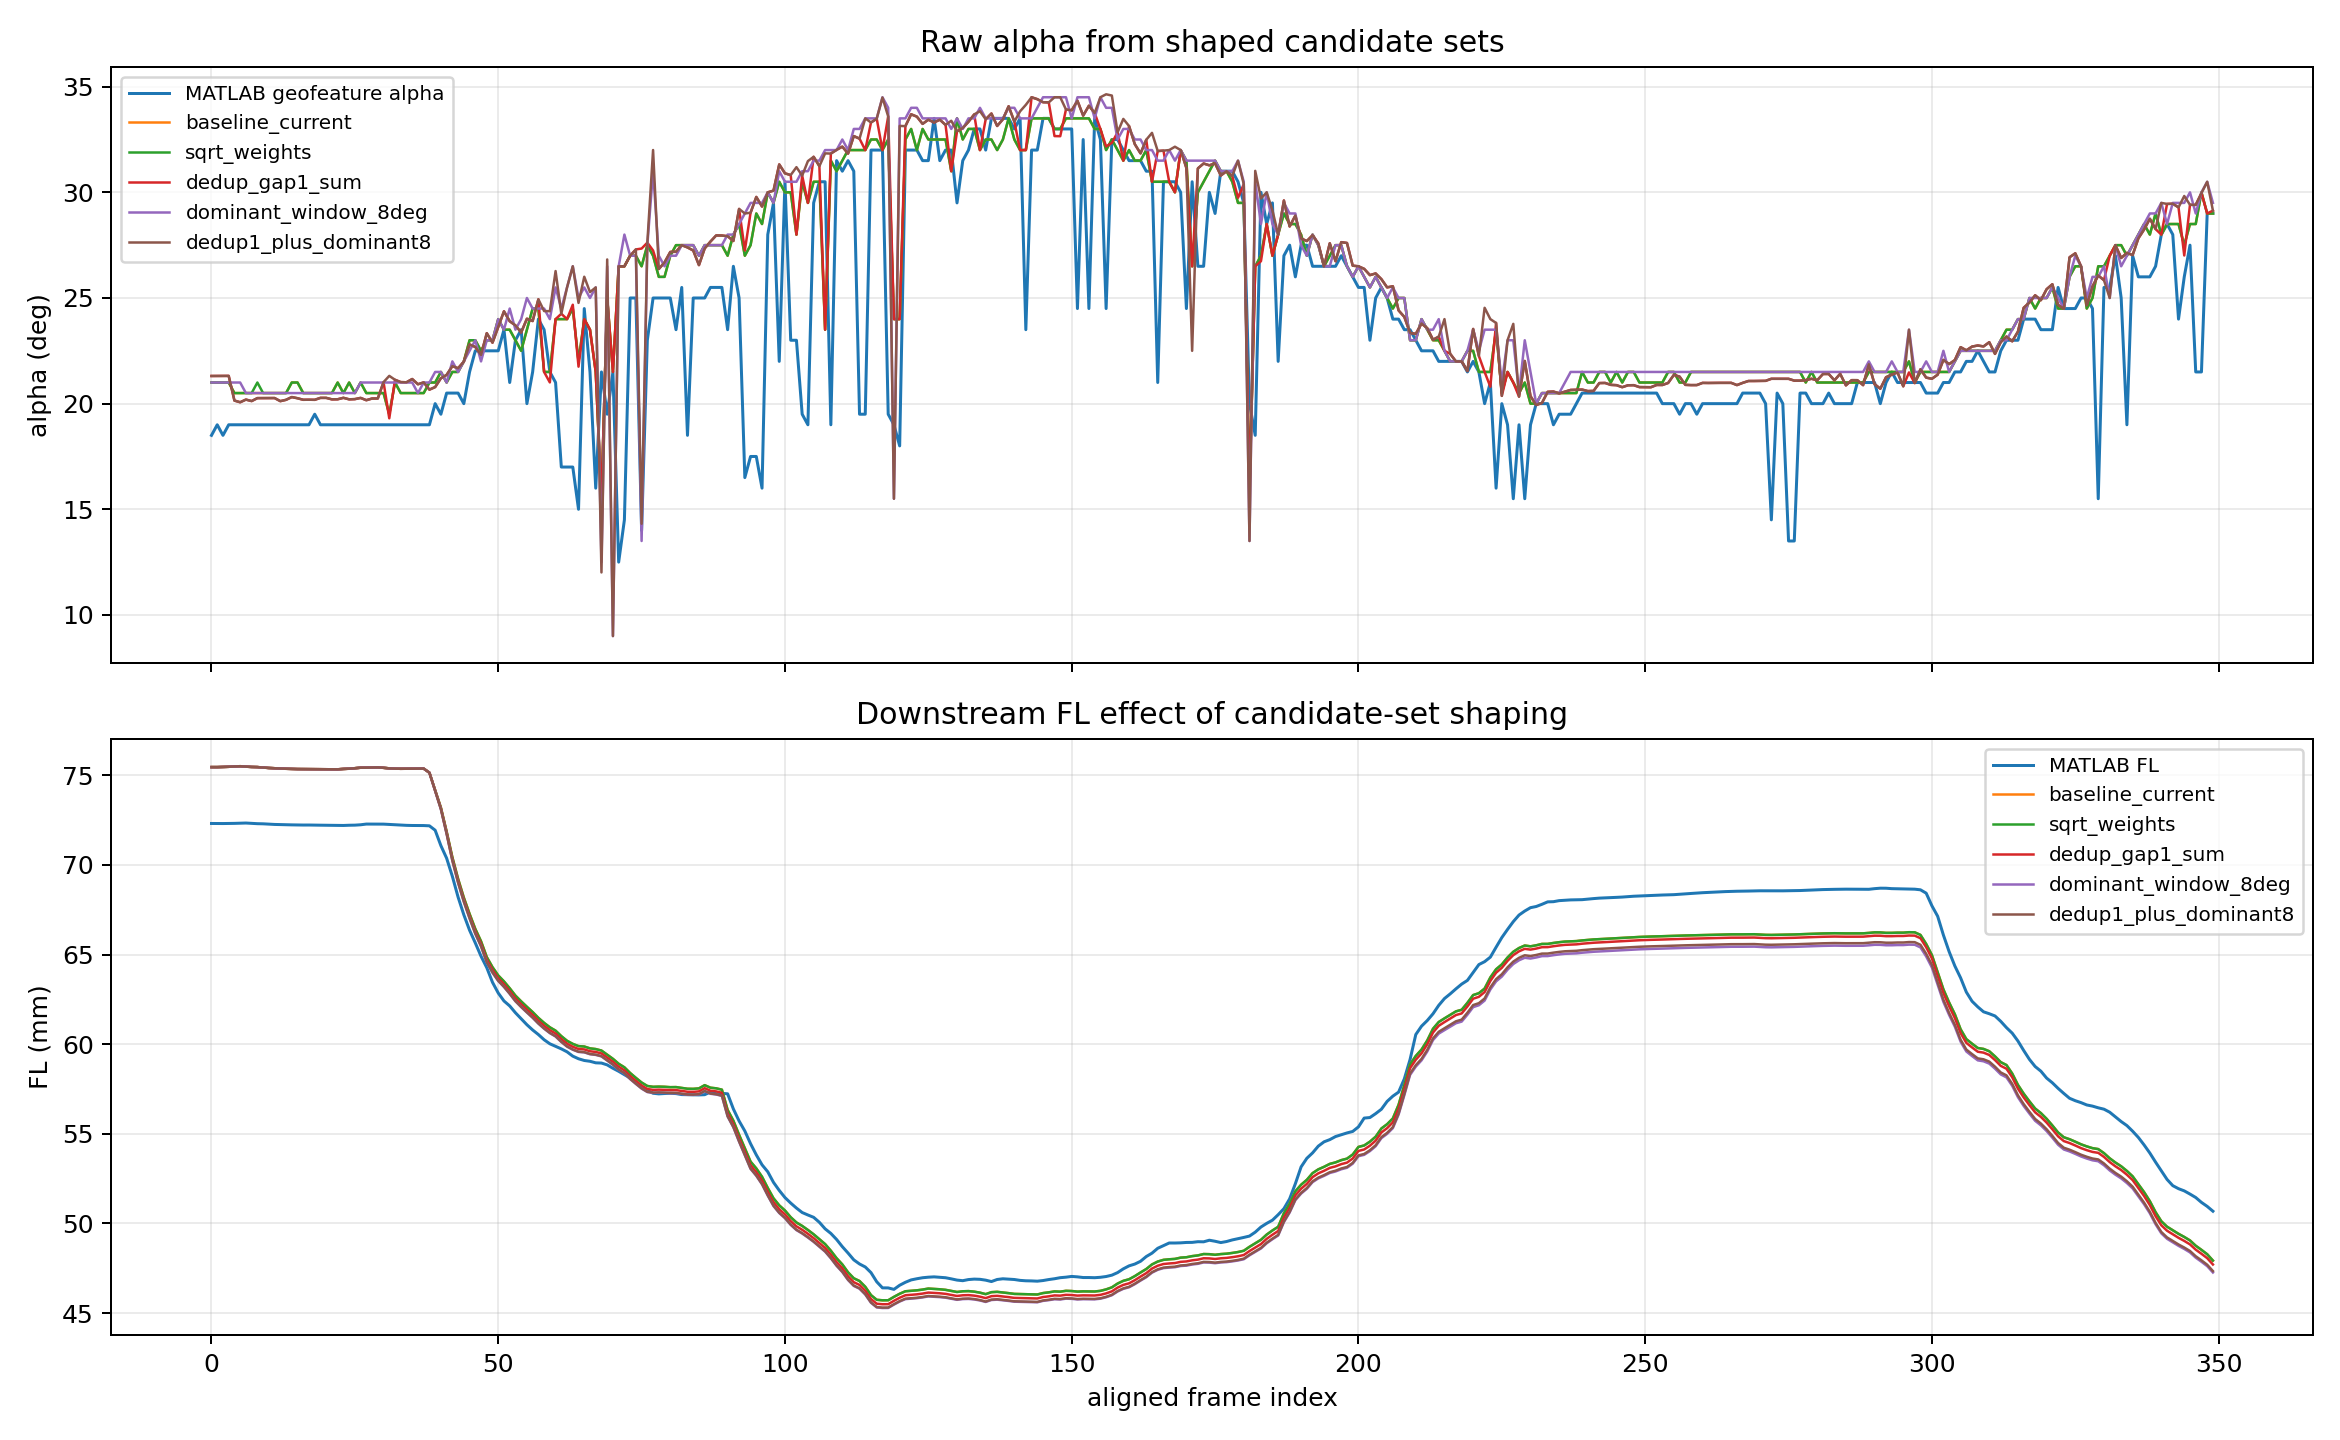

In [4]:
display(Image(filename=str(OUT / 'shaping_variant_summary.png')))
display(Image(filename=str(OUT / 'shaping_variant_traces.png')))